In [1]:
import random
import ast
import inspect
import instructor
import json

import openai

from pydantic import BaseModel, Field
from jinja2 import Template
from typing import Literal, Dict, Any, Annotated, List
from operator import add

from IPython.display import Image, display

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode

from langchain_core.messages import AIMessage, HumanMessage, ToolMessage, convert_to_openai_messages, convert_to_messages

from langsmith import traceable

from qdrant_client import QdrantClient
from qdrant_client.models import (
    Filter,
    FieldCondition,
    MatchValue,
    VectorParams,
    Distance,
    SparseVectorParams,
    Modifier,
    PayloadSchemaType,
    Document,
    PointStruct,
    Prefetch,
    FusionQuery,
    RrfQuery,
    Rrf
)

from utils.utils import get_tool_descriptions, format_ai_message

/Users/vaidasarmonas/Learning/AI-Engineering-Bootcamp/.venv/lib/python3.14/site-packages/langchain_core/_api/deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


### Agent Graph with Loopback from Tools (ReAct Agent)

### Retrieval Tool

In [2]:
@traceable(
    name="embed_query",
    run_type="embedding",
    metadata={"ls_provider": "openai", "ls_model": "text_embedding_3_small"}
)
def get_embedding(text, model='text-embedding-3-small'):

    response = openai.embeddings.create(
        input=text,
        model=model
    )

    return response.data[0].embedding

@traceable(
    name="retrieve_data",
    run_type='retriever'
)
def retrieve_data(query, k=5):

    qdrant_client = QdrantClient(url="http://localhost:6333")
   
    query_embedding = get_embedding(query)
    results = qdrant_client.query_points(
        collection_name="Amazon-items-collection-01-hybrid-search",
        prefetch=[
            Prefetch(
                query=query_embedding,
                using="text-embedding-3-small",
                limit=20
            ),
            Prefetch(
                query=Document(
                    text=query,
                    model="qdrant/bm25",
                ),
                using="bm25",
                limit=20
            )
        ],
        query=RrfQuery(rrf=Rrf(weights=[1,1])),
        limit=k
    )

    retrieved_context_ids = []
    retrieved_context = []
    similarity_scores = []
    retrieved_context_ratings = []
    for result in results.points:
        retrieved_context_ids.append(result.payload["parent_asin"])
        retrieved_context.append(result.payload["description"])
        similarity_scores.append(result.score)
        retrieved_context_ratings.append(result.payload["average_rating"])

    return {
        "retrieved_context_ids": retrieved_context_ids,
        "retrieved_context": retrieved_context,
        "similarity_scores": similarity_scores,
        "retrieved_context_ratings": retrieved_context_ratings
    }

@traceable(
    name="format_retrieved_context",
    run_type="prompt"
)
def process_context(context):
    
    formatted_context = ""

    for id, chunk, rating in zip(context["retrieved_context_ids"], context["retrieved_context"], context["retrieved_context_ratings"]):
        formatted_context += f"- ID: {id}, rating: {rating}, description: {chunk}\n"

    return formatted_context

def get_formatted_item_context(query: str, top_k: int = 5) -> str:
    """Get the context for top k items - each item is an inventory item for a given query.

    Args:
        query: The query to get the top k items for
        top_k: The number of items and context to retrieve, works best with 5 or more

    Returns:
        A string representing context for top_k items from inventory for a given query. Information returned - IDs, average rating and description of item.
    """
    context = retrieve_data(query, top_k)

    return process_context(context)

### State and Pydantic Models for Structured Outputs

In [3]:
class ToolCall(BaseModel):
    name: str = Field(description="Name of the tool to call")
    arguments: dict = Field(description="Arguments for the tool call")

class RAGUsedContext(BaseModel):
    id: str = Field(description="ID of the item used to answer the question")
    description: str = Field(description="Short description of the item used to answer the question")

class AgentResponse(BaseModel):
    answer: str
    references: List[RAGUsedContext] = Field(description="List of items used to answer the question")
    final_answer: bool = False
    tool_calls: List[ToolCall] = []

class State(BaseModel):
    messages: Annotated[List[Any], add] = []
    question_relevant: bool = False
    message: str = ""
    iteration: int = 0
    answer: str = ""
    available_tools: List[Dict[str, Any]] = []
    tool_calls: List[ToolCall] = []
    final_answer: bool = False
    references: Annotated[List[RAGUsedContext], add] = []

In [4]:
@traceable(
    name="agent_node",
    run_type="llm",
    metadata={"ls_provider": "openai", "ls_model_name": "gpt-4.1-mini"}
)
def agent_node(state: State) -> dict:
    
    prompt_template = """You are a shopping assistant that answers customer questions about products currently in stock.

## Tools

<available_tools>
{{ available_tools | tojson }}
</available_tools>

Use only the tool names listed above, exaactly as written.
Place all parameters inside the "arguments" object.

## Tool call examples

- Search for products:
{"name": "get_formatted_item_context", "arguments"": {"query": "toys for kids under 5", "top_k": 5}}

## Instructions

- Do not ask for clarifications. Do the best you can with the information you have in the query.
- Use the available tools to answer product questions. Do not fabricate product details.
- When a question involves multiple products or sub-questions, issue all tool calls at once. Never repeat a tool call you already made.
- When a question involves multiple products, break down the query into multiple queries for the tool call.
- When describing products, include detailed specifications in bullet points.
- If tools return no relevant results, tell the customer and ask them to refine their query.
- Only answer questions about products in stock. If a question is unrelated, ask the customer to clarify what product they are interested in.
- In references, include every chunk that contributed to your answer with the chunk id and product name.
- Refer to retrieved data as "available products", never as "context".
- Try answering queries that are not precise, if specfiic names or brands are missing apply broad searches.
"""
    prompt = Template(prompt_template).render(available_tools=state.available_tools)
    
    if state.iteration == 0:
        conversation = []
        conversation.append({'role': 'user', 'content': state.message})
    else:
        conversation = []
        for message in state.messages:
            conversation.append(convert_to_openai_messages(message))

    client = instructor.from_provider(
        model="openai/gpt-4.1-mini"
    )

    response, raw_response = client.create_with_completion(
        messages=[
            {"role": "system", "content": prompt},
            *conversation
        ],
        response_model=AgentResponse
    )
    ai_message = format_ai_message(response)
    if state.iteration == 0:
        messages = [HumanMessage(state.message), ai_message]
    else:
        messages = [ai_message]
    return {
        "messages": messages,
        "tool_calls": response.tool_calls,
        "iteration": state.iteration + 1,
        "answer": response.answer,
        "final_answer": response.final_answer,
        "references": response.references
    }

In [5]:
def tool_router(state: State) -> str:
    
    if state.final_answer:
        return "end"
    
    elif len(state.tool_calls) > 0:
        return "tools"
    
    return "end"

### User Intent Router Node

In [6]:
class IntentRouterNode(BaseModel):
    question_relevant: bool
    answer: str

In [7]:
@traceable(
    name="intent_router",
    run_type="llm",
    metadata={"ls_provider": "openai", "ls_model_name": "gpt-4.1-mini"}
)
def intent_router_node(state: State) -> dict:

    prompt_template = """You are a relevance router for a shopping assistant that answers question about products in stock.
You will be given a question and a list of context.

## Instructions

- Determine whether the question is about products, inventory or purchasing.
- Questions about product features, availability, pricing, comparisons, and recommendations are relevant.
- Questions about store policies, personal advice, or unrelated topics are not relevant.
- If the questions is not relevant, add reason for it in the "answer" output field.

## Examples

Question: "Do you have running shoes under $100?"
Relevant: yes

Question: "What's the weather like today?"
Relevant: no - not related to products

Question: "Can you help me write an essay?"
Relevant: no - not relevant to products

Question: "Which laptop has the best battery life?"
Relevant: yes

Question: "What's your return policy?"
Relevant no - about store policy, not product information

<question>
{{ question }}
</question>
    """

    prompt = Template(prompt_template).render(
        question=state.message
        )

    client = instructor.from_provider(
        "openai/gpt-4.1-mini"
    )

    response, raw_response = client.create_with_completion(
        messages=[
            {
                "role": "system",
                "content": prompt
            }
        ],
        response_model=IntentRouterNode
    )

    return {
        "question_relevant": response.question_relevant,
        "answer": response.answer
    }

In [8]:
def intent_router_conditional_edges(state: State) -> str:

    if state.question_relevant:
        return "agent_node"
    
    return "end"

In [9]:
workflow = StateGraph(State)

tools = [get_formatted_item_context]
tool_node = ToolNode(tools)
tool_descriptions = get_tool_descriptions(tools)

In [10]:
workflow.add_node("tool_node", tool_node)
workflow.add_node("agent_node", agent_node)
workflow.add_node("intent_router_node", intent_router_node)

workflow.add_edge(START, "intent_router_node")
workflow.add_conditional_edges(
    "intent_router_node",
    intent_router_conditional_edges,
    {
        "agent_node": "agent_node",
        "end": END
    }
)
workflow.add_conditional_edges(
    "agent_node",
    tool_router,
    {
        "tools": "tool_node",
        "end": END
    }
)
workflow.add_edge("tool_node", "agent_node")
graph = workflow.compile()

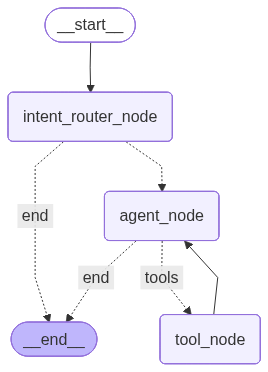

In [11]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [12]:
QUERY = "I want to buy a book for my son, who is 6, and a fiction book for myself."

initial_state = {
    "message": QUERY,
    "available_tools": tool_descriptions
}

In [13]:
result = graph.invoke(initial_state)

In [14]:
result

{'messages': [HumanMessage(content='I want to buy a book for my son, who is 6, and a fiction book for myself.', additional_kwargs={}, response_metadata={}),
  AIMessage(content='I will look for books suitable for your 6-year-old son and fiction books for adults in the inventory to provide you with the best options.', additional_kwargs={}, response_metadata={}, tool_calls=[{'name': 'get_formatted_item_context', 'args': {'query': 'books for 6 year old children', 'top_k': 3}, 'id': 'call_0', 'type': 'tool_call'}, {'name': 'get_formatted_item_context', 'args': {'query': 'fiction books for adults', 'top_k': 3}, 'id': 'call_1', 'type': 'tool_call'}], invalid_tool_calls=[]),
  ToolMessage(content='- ID: B09Y98N9R4, rating: 4.4, description: Crossword puzzles for kids Ages 8 – 9: 50 full-color illustrated themes - 50 varied and fun grids with definitions and pictures that will guide children. Activity book for children. Crossword puzzles for kids Ages 8 – 9 This fun book is made of 50 crosswor

In [15]:
print(result['answer'])

For your 6-year-old son, here are some suitable book options:
- "Crossword puzzles for kids Ages 8 – 9": This book contains 50 full-color illustrated themes with varied crossword puzzles that help improve vocabulary and spelling. It is designed for slightly older kids but may be suitable with guidance.
- "Toddler Books About Balls": A wordless picture book with real photos that develops observation, language, vocabulary, and color recognition skills.
- "Sela Explores The River": An award-winning children's picture book for ages 2-6 about nature and exploration, inspired by Pacific Northwest landscapes.

For a fiction book for yourself, here are some available options:
- "Testing Limits (Corrupt Cowboys)": A dark, adult fiction book full of drama and complex characters. Intended for readers 18+.

Unfortunately, there are no typical adult fiction novels currently available in the inventory, but the above title is a fiction option with a mature theme.

Let me know if you want more options

In [16]:
QUERY_NOT_RELEVANT = "What's the weather?"

initial_state = {
    "message": QUERY_NOT_RELEVANT,
    "available_tools": tool_descriptions
}

In [17]:
result = graph.invoke(initial_state)

In [18]:
result

{'messages': [],
 'question_relevant': False,
 'message': "What's the weather?",
 'answer': 'The question is not relevant as it asks about the weather, which is unrelated to products, inventory, or purchasing.',
 'available_tools': [{'name': 'get_formatted_item_context',
   'description': 'Get the context for top k items - each item is an inventory item for a given query.',
   'parameters': {'type': 'object',
    'properties': {'query': {'type': 'string',
      'description': 'The query to get the top k items for'},
     'top_k': {'type': 'integer',
      'description': 'The number of items and context to retrieve, works best with 5 or more',
      'default': 5}},
    'required': ['query']},
   'returns': {'type': 'string',
    'description': 'A string representing context for top_k items from inventory for a given query. Information returned - IDs, average rating and description of item.'}}],
 'references': []}